<a href="https://colab.research.google.com/github/Zach-Kaplan44/econ5200-lab03-eda-diagnostics/blob/main/lab_ch03_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Pipeline Health Check — Finding Data Corruption Through EDA

**ECON 5200: Causal Machine Learning & Applied Analytics**

This lab uses a **diagnosis-first** format. You will:
1. Find and fix 5 planted data quality issues in a deliberately corrupted dataset using EDA alone
2. Build automated distribution diagnostics that detect shifts between training and inference data
3. Compare manual EDA to automated profiling (ydata-profiling) and identify what each misses
4. Write a reusable `eda_utils.py` module with distribution checking and anomaly detection functions

**Time estimate:** 45-60 minutes

**Prerequisites:** Chapter 3 reading, including [5200-DEPTH] sections on distribution diagnostics and data pipeline monitoring

**AI in the manual parts:** you may ask Colab to *explain* an error or a line of code (click **Explain error**, or select a line and ask Gemini to explain it). Do not ask it to write or fix code, and turn off AI code completion while you work on those parts. AI-assisted coding is allowed only where this lab says so.

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("Setup complete!")

Setup complete!


<!-- 5200-onramp -->
## Part 0: Build It First (GUIDED — 15 min)

Part 1 hands you a merged dataset with five things wrong with it and asks you
to find them all using EDA alone. Before you can spot corruption, you need to
know what a healthy profile of a clean panel looks like, and you need the
pandas verbs that produce one.

**This lab's slice of the floor:** `.groupby()`, `.map()` / `.apply()`, the
three loop helpers you will read constantly (`zip`, `enumerate`, `range`), and
`try` / `except`.

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0a: groupby, map, apply
# -----------------------------------------------------------
import pandas as pd
import numpy as np

clean = pd.DataFrame({
    "country":   ["USA", "USA", "China", "China", "Brazil", "Brazil"],
    "year":      [2022, 2023, 2022, 2023, 2022, 2023],
    "gdp":       [25.7, 27.4, 17.9, 18.5, 1.92, 2.17],     # trillions USD
    "region":    ["Americas", "Americas", "Asia", "Asia", "Americas", "Americas"],
})

# .groupby(col) SPLITS the table into one group per distinct value, APPLIES an
# aggregation to each, and COMBINES the answers. Split -> apply -> combine.
print("Mean GDP by region:")
print(clean.groupby("region")["gdp"].mean().round(2))

# Note what came back: a Series whose INDEX is the region. groupby always turns
# the grouping column into the index. .reset_index() pushes it back to a column.
print("\nSeveral statistics at once — .agg():")
print(clean.groupby("country")["gdp"].agg(["count", "mean", "max"]).round(2))

# .map() applies a function to EVERY VALUE of a Series and returns a new one.
# `lambda x: ...` is a one-expression function with no name, handed to .map()
# so it can be run once per value.
clean["gdp_billions"] = clean["gdp"].map(lambda x: x * 1000)

# .map() also takes a DICT, which is how you recode labels.
clean["region_code"] = clean["region"].map({"Americas": "AM", "Asia": "AS"})

# .apply(axis=1) hands your function an entire ROW rather than one value.
clean["label"] = clean.apply(
    lambda row: f"{row['country']} {row['year']}: ${row['gdp']:.2f}T", axis=1
)
print("\n" + "\n".join(clean["label"]))

Mean GDP by region:
region
Americas    14.3
Asia        18.2
Name: gdp, dtype: float64

Several statistics at once — .agg():
         count   mean    max
country                     
Brazil       2   2.04   2.17
China        2  18.20  18.50
USA          2  26.55  27.40

USA 2022: $25.70T
USA 2023: $27.40T
China 2022: $17.90T
China 2023: $18.50T
Brazil 2022: $1.92T
Brazil 2023: $2.17T


In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0b: the loop helpers, and try / except
# -----------------------------------------------------------

countries = ["USA", "China", "Brazil"]
gdp       = [27.4, 18.5, 2.17]

# zip() walks two lists side by side, one pair per step.
for name, value in zip(countries, gdp):
    print(f"  {name:<8}${value:>6.2f}T")

# enumerate() walks a list while counting positions — `i` is 0, 1, 2 ...
# This is the form you will read in every multi-panel plotting cell.
print()
for i, name in enumerate(countries):
    print(f"  panel {i}: {name}")

# range(n) repeats n times. The throwaway `_` means "I do not need this value".
total = 0
for _ in range(3):
    total += 1
print(f"\nRepeated 3 times, total = {total}")

# try / except catches ONE SPECIFIC failure and carries on. Always name the
# exception you expect; a bare `except:` swallows real bugs and leaves you
# debugging blind.
raw = ["3.1", "2.5", "n/a", "4.5", ""]
cleaned = []
for item in raw:
    try:
        cleaned.append(float(item))
    except ValueError:
        cleaned.append(np.nan)      # np.nan is "missing number"
print(f"\nRaw:     {raw}")
print(f"Cleaned: {cleaned}")

  USA     $ 27.40T
  China   $ 18.50T
  Brazil  $  2.17T

  panel 0: USA
  panel 1: China
  panel 2: Brazil

Repeated 3 times, total = 3

Raw:     ['3.1', '2.5', 'n/a', '4.5', '']
Cleaned: [3.1, 2.5, nan, 4.5, nan]


In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0c: BUILD IT — what a HEALTHY profile looks like
# -----------------------------------------------------------
# Part 1 hands you a corrupted version of a panel shaped exactly like this one.
# Run the same four checks on clean data first, so you know what "fine" reads
# like. These four are the whole EDA checklist:
#
#     STRUCTURE     — shape, dtypes, one row per what?
#     DISTRIBUTIONS — describe(): any impossible values?
#     COMPLETENESS  — nulls, and duplicate keys
#     RANGES        — does every column obey its domain constraint?

rng = np.random.default_rng(42)
n_c, yrs = 10, list(range(2000, 2024))
healthy = pd.DataFrame([
    {"country": c, "year": y,
     "gdp": rng.uniform(500, 25000),
     "population": rng.uniform(5, 1400),
     "life_expectancy": rng.uniform(55, 85),
     "trade_pct": rng.uniform(20, 85)}
    for c in [f"C{i}" for i in range(n_c)] for y in yrs
])

print("1. STRUCTURE")
print(f"   shape {healthy.shape} — expect {n_c} countries x {len(yrs)} years = {n_c * len(yrs)}")
print(f"   one row per country-year? duplicates: "
      f"{healthy.duplicated(subset=['country', 'year']).sum()}")

print("\n2. DISTRIBUTIONS")
print(healthy[["gdp", "population", "life_expectancy", "trade_pct"]]
      .describe().loc[["min", "50%", "max"]].round(1).to_string())

print("\n3. COMPLETENESS")
print(f"   nulls per column: {healthy.isna().sum().sum()} total")

print("\n4. RANGES — every column against its domain constraint")
constraints = {"gdp": (0, 1e6), "population": (0, 2000),
               "life_expectancy": (0, 120), "trade_pct": (0, 200)}
for col, (lo, hi) in constraints.items():
    bad = ((healthy[col] < lo) | (healthy[col] > hi)).sum()
    print(f"   {col:<18} outside [{lo}, {hi}]: {bad}")

1. STRUCTURE
   shape (240, 6) — expect 10 countries x 24 years = 240
   one row per country-year? duplicates: 0

2. DISTRIBUTIONS
         gdp  population  life_expectancy  trade_pct
min    540.7        17.9             55.1       20.1
50%  12514.8       719.5             69.0       53.4
max  24940.7      1398.8             84.8       84.9

3. COMPLETENESS
   nulls per column: 0 total

4. RANGES — every column against its domain constraint
   gdp                outside [0, 1000000.0]: 0
   population         outside [0, 2000]: 0
   life_expectancy    outside [0, 120]: 0
   trade_pct          outside [0, 200]: 0


### Now diagnose

Every number above is what healthy looks like: no duplicate keys, no nulls, no
value outside its domain, and a `describe()` whose min and max are plausible
for what the column claims to measure.

Part 1's dataset fails several of these. Run the same four checks on it and let
the *contrast* tell you where to look — that is faster and far more reliable
than reading the generating code, and it is what you would actually do with a
pipeline you did not write.

---

## Part 1: The Corrupted Dataset (DIAGNOSTIC — 20 min)

The following code generates a realistic economic dataset merged from three sources. **Something went wrong during the merge.** Using only EDA techniques from Chapter 3, find ALL 5 data quality issues before fitting any model.

**Challenge:** This dataset was merged from three sources. Five things went wrong. Using only EDA techniques from Chapter 3, find ALL data quality issues, explain what's wrong, and fix each one.

In [ ]:
# -----------------------------------------------------------
# GIVEN — Run as-is. This generates the corrupted dataset.
# Do NOT modify this cell.
# -----------------------------------------------------------
np.random.seed(42)

countries = ["USA", "China", "India", "Brazil", "Germany",
             "Japan", "UK", "France", "Canada", "Australia"]
years = list(range(2000, 2024))
n_base = 240  # 10 countries x 24 years

# --- Source 1: Main dataset (clean) ---
rows = []
for c in countries:
    for y in years:
        gdp = np.random.uniform(500, 25000)  # GDP in millions USD
        pop = np.random.uniform(5, 1400)      # population in millions
        le = np.random.uniform(55, 85)         # life expectancy in years
        trade = np.random.uniform(20, 85)      # trade as % of GDP
        rows.append([c, y, gdp, pop, le, trade])

df = pd.DataFrame(rows, columns=["country", "year", "gdp", "population",
                                  "life_expectancy", "trade_pct"])

# --- corruption 1 ---
neg_idx = np.random.choice(df.index, size=10, replace=False)
df.loc[neg_idx, "gdp"] = df.loc[neg_idx, "gdp"] * -1

# --- corruption 2 ---
month_idx = np.random.choice(df.index, size=15, replace=False)
df.loc[month_idx, "life_expectancy"] = df.loc[month_idx, "life_expectancy"] * 12

# --- corruption 3 ---
dup_idx = np.random.choice(df.index, size=20, replace=False)
dup_rows = df.loc[dup_idx].copy()
# Slightly perturb duplicates so they aren't exact copies
dup_rows["gdp"] = dup_rows["gdp"] * np.random.uniform(0.98, 1.02, size=20)
df = pd.concat([df, dup_rows], ignore_index=True)

# --- corruption 4 ---
# Some rows stored as decimals (0.45) instead of percentages (45%)
decimal_idx = np.random.choice(df.index, size=30, replace=False)
df.loc[decimal_idx, "trade_pct"] = df.loc[decimal_idx, "trade_pct"] / 100
# Some rows have impossible values (data entry: 350%, 450%)
impossible_idx = np.random.choice(
    df.index.difference(decimal_idx), size=10, replace=False
)
df.loc[impossible_idx, "trade_pct"] = np.random.uniform(200, 500, size=10)

# --- corruption 5 ---
unit_idx = np.random.choice(df.index, size=50, replace=False)
df.loc[unit_idx, "gdp"] = df.loc[unit_idx, "gdp"] / 1000

# Shuffle so bugs aren't at the end
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (260, 6)
Columns: ['country', 'year', 'gdp', 'population', 'life_expectancy', 'trade_pct']


In [ ]:
# -----------------------------------------------------------
# GIVEN — Inspect the data. The bugs are visible if you look.
# -----------------------------------------------------------
print("=== First 10 rows ===")
display(df.head(10))

print("\n=== Summary statistics ===")
display(df.describe().round(2))

print("\n=== Value counts: country-year pairs with > 1 entry ===")
dupes = df.groupby(["country", "year"]).size()
print(dupes[dupes > 1].head(10))

=== First 10 rows ===


,country,year,gdp,population,life_expectancy,trade_pct
0,China,2006,-20282.283802,1255.047363,64.540104,27.153375
1,France,2013,14.574591,1179.351144,59.193171,71.692375
2,Australia,2007,20840.386682,559.071024,75.042554,33.323979
3,France,2017,11835.654749,425.422134,77.428281,52.676825
4,Canada,2019,4142.236830,583.400653,57.560490,84.796826
5,India,2022,22588.704226,476.503244,66.267489,26.108826
6,France,2005,12936.454278,343.161577,58.445105,252.232801
7,Japan,2022,22651.888015,490.816376,70.419685,432.396059
8,USA,2009,7963.037345,141.252599,75.526991,48.609912
9,France,2009,6738.696042,955.696298,77.806836,58.716518



=== Summary statistics ===


,year,gdp,population,life_expectancy,trade_pct
count,260.00,260.00,260.00,260.00,260.00
mean,2011.58,8854.18,703.13,113.81,58.07
std,6.89,9439.48,400.46,177.83,60.77
min,2000.00,-20282.28,11.46,55.36,0.28
25%,2006.00,864.22,350.45,60.96,31.75
50%,2012.00,7499.43,726.08,69.77,52.35
75%,2017.25,16692.29,1032.85,77.69,70.38
max,2023.00,24917.60,1386.13,1009.17,432.40



=== Value counts: country-year pairs with > 1 entry ===
country    year
Australia  2001    2
           2011    2
Brazil     2002    2
Canada     2008    2
           2017    2
China      2005    2
France     2012    2
           2015    2
           2020    2
Germany    2013    2
dtype: int64


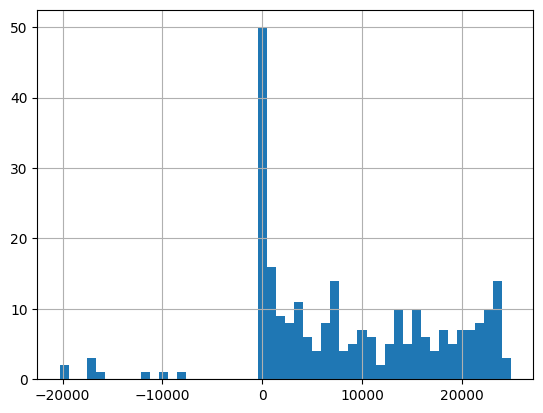

22      0.275315
159     0.289389
143     0.304794
178     0.319213
232     0.375984
29      0.431890
142     0.472302
86      0.476534
99      0.482004
245     0.491490
220     0.494086
229     0.526714
130     0.589128
46      0.603201
241     0.649732
125     0.652383
224     0.669594
169     0.673341
154     0.679722
28      0.686369
129     0.726418
56      0.728967
238     0.739332
223     0.762580
83      0.770180
118     0.770357
200     0.799218
181     0.814098
259     0.817540
252     0.824696
35     20.704447
63     20.945403
106    21.078209
40     21.184419
153    21.713853
206    22.427632
242    22.656460
84     22.944761
255    24.131293
251    24.271062
Name: trade_pct, dtype: float64
98      81.718841
137     82.832563
109     83.042124
79      83.044140
188     83.165835
74      83.854610
107     84.103698
114     84.542712
4       84.796826
111     84.981649
164    229.518695
6      252.232801
257    255.558670
235    279.513928
227    288.960674
65     304.910969


In [ ]:
df["gdp"].hist(bins=50)
plt.show()

df["life_expectancy"].sort_values().tail(20)

print(df["trade_pct"].sort_values().head(40))
print(df["trade_pct"].sort_values().tail(20))

### Your Diagnosis

For each of the 5 bugs, write:
1. **What is wrong** (1 sentence identifying the specific issue)
2. **How you found it** (which EDA technique — describe output, histogram, scatter, etc.)
3. **Why it matters** (what downstream analysis would this corrupt?)
4. **Your fix** (show corrected code)

---

**Bug 1** — name it yourself:

*Your answer here:* GDP is saved in different units. From looking at a histogram, we can see one massive hump, indicating that some countries are off by a scale. Any further analysis on GDP will be corrupted as analysis can't be done on mismatching units.

**Bug 2** — name it yourself:

*Your answer here:* From looking at the data structure, there are multiple country-year pairs that have multiple entries in them. This can affect median values, and analysis of any measurements in those years or countries.

**Bug 3** — name it yourself:

*Your answer here:* From looking at the data output, we can see that the values of life expectancy are off. A max of 1009.17 is impossible. From looking at the 20 highest values, there is a massive jump between the plausible and implausible values. If you divide the implausible values by 12, they become plausible, meaning that some of the life expectancy data is stored in months.

**Bug 4** — name it yourself:

*Your answer here:* From examining both the minimum GDP value, as well as the histogram, we can see that there are GDP values in the negatives which is impossible. Because of this any analysis of mean GDP will be skewed downwards.

**Bug 5** — name it yourself:

*Your answer here:* From examining the data output we can see that the minimum and maximum trade values are implausible. If we look at the smallest and largest values, we can see two clear cutoff points where the percentages make a jump, one where they jump from decimals, indicating that percentages were accidentally converted to decimals, and another where the trade percentages jump to an implausibly high number. Any downstream analysis of trade percentages will be off when examining countries whose perecentages are in decimal format.

In [ ]:
# -----------------------------------------------------------
# YOUR FIXES — Clean the dataset
# -----------------------------------------------------------

df_clean = df.copy()

# FIX 1: Negative GDP → take absolute value
# YOUR CODE HERE
neg = df_clean["gdp"] < 0
df_clean.loc[neg, "gdp"] = df_clean.loc[neg, "gdp"].abs()

# FIX 2: Life expectancy stored as months → divide by 12
# (Values > 120 are clearly months, not years)
# YOUR CODE HERE
months = df_clean["life_expectancy"] > 120
df_clean.loc[months, "life_expectancy"] = df_clean.loc[months, "life_expectancy"]/12

# FIX 3: Remove duplicate country-year pairs (keep first)
# YOUR CODE HERE
df_clean = df_clean.drop_duplicates(subset=["country", "year"])

# FIX 4: Standardize trade_pct
# Values < 1 are decimals → multiply by 100
# Above 100% is real: Singapore and Luxembourg re-export, so gross trade can
# exceed value added. The corrupt rows here sit at 200–500%. Pick your cutoff
# from that gap, and say whether you drop or cap — and why.
# YOUR CODE HERE
dec = df_clean["trade_pct"] < 1
df_clean.loc[dec, "trade_pct"] *= 100
df_clean.loc[df_clean["trade_pct"] > 200, "trade_pct"] = 100

# I chose to cap rather than drop.
# Capping the corrupt data points at 100 puts them at a more plausible value, and avoids losing legitimate measurements in other columns.
# FIX 5: GDP unit mismatch
# Legitimate GDP runs from about 500 to 25,000 (millions USD). The corrupted
# rows were divided by 1,000, so they land in [0.5, 25] — far below anything
# real, but mostly ABOVE 1. Pick the threshold from the gap between the two
# ranges, not from the value 1: anything under 100 is in thousands.
# Values < 100 are in thousands, not millions → multiply by 1000

#
# Why is the column in millions at all? A GDP column has to hold Tuvalu and
# the United States in the same dtype — six orders of magnitude. Choose the
# unit from the SMALLEST value you must represent, not the largest: in
# millions the tiniest economies are still readable whole numbers, where in
# billions they round toward 0.06 and in trillions they vanish. That is why
# the UN National Accounts and Eurostat both publish in millions. It is also
# why this bug is findable: in millions the clean rows sit at 500–25,000 and
# the corrupted ones at [0.5, 25], a clean factor of 1,000 apart. Had the
# column been in trillions, the legitimate values would already be 0.5–25 —
# sitting exactly on top of the corruption, with no gap to find.
# YOUR CODE HERE
thou = df_clean["gdp"] < 100
df_clean.loc[thou, "gdp"] *= 100

print(f"Cleaned shape: {df_clean.shape}")
display(df_clean.describe().round(2))

Cleaned shape: (240, 6)


,year,gdp,population,life_expectancy,trade_pct
count,240.00,240.00,240.00,240.00,240.00
mean,2011.50,10054.62,710.15,68.70,56.37
std,6.94,7980.24,402.43,8.82,20.29
min,2000.00,85.26,11.46,55.36,20.70
25%,2005.75,2193.25,352.22,60.18,40.44
50%,2011.50,8041.05,736.86,68.17,55.78
75%,2017.25,17313.93,1035.37,76.09,72.72
max,2023.00,24917.60,1386.13,84.72,100.00


### Verification Checkpoint

After fixing all 5 bugs, `df_clean.describe()` should show:
- **GDP:** min > 0, max in the low thousands to ~25,000 range
- **life_expectancy:** min > 50, max < 100
- **No duplicates:** `df_clean.duplicated(subset=['country', 'year']).sum()` == 0
- **trade_pct:** min > 0, max <= 100

Run the cell below to verify:

In [ ]:
# -----------------------------------------------------------
# VERIFICATION — Run after your fixes
# -----------------------------------------------------------
checks = {
    "GDP all positive": df_clean["gdp"].min() > 0,
    "Life expectancy max < 100": df_clean["life_expectancy"].max() < 100,
    "No duplicate country-years": df_clean.duplicated(
        subset=["country", "year"]
    ).sum() == 0,
    "Trade pct max <= 100": df_clean["trade_pct"].max() <= 100,
    "Trade pct min > 0": df_clean["trade_pct"].min() > 0,
}

all_pass = True
for name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    print(f"  [{status}] {name}")
    if not passed:
        all_pass = False

print()
if all_pass:
    print("All checks passed! Dataset is clean.")
else:
    print("Some checks failed. Review your fixes above.")

  [PASS] GDP all positive
  [PASS] Life expectancy max < 100
  [PASS] No duplicate country-years
  [PASS] Trade pct max <= 100
  [PASS] Trade pct min > 0

All checks passed! Dataset is clean.


## Part 2: Distribution Shift Detection (EXTEND — 15 min)

A clean dataset today doesn't guarantee a clean dataset tomorrow. In production, the data generating process can change — a new data source, a policy shock, a pandemic. This section builds a diagnostic that detects when the distribution of incoming data has drifted from the training data.

In [ ]:
# -----------------------------------------------------------
# GIVEN — Split into training and inference sets
# Deliberately shift GDP in the inference set
# -----------------------------------------------------------

# Use cleaned data from Part 1
# Split proportionally, not at a fixed row number — the dataset is 260 rows
# before your FIX 3 removes duplicates, so any hard-coded index near 300
# leaves the inference set empty.
split = int(len(df_clean) * 0.6)
train = df_clean.iloc[:split].copy()
inference = df_clean.iloc[split:].copy()

# Simulate a distribution shift: inference GDP is 30% higher
# (e.g., new data source reports GDP in a different unit)
inference["gdp"] = inference["gdp"] * 1.3

print(f"Training set: {len(train)} rows")
print(f"Inference set: {len(inference)} rows")
print(f"\nTraining GDP mean: {train['gdp'].mean():.0f}")
print(f"Inference GDP mean: {inference['gdp'].mean():.0f}")

Training set: 144 rows
Inference set: 96 rows

Training GDP mean: 9434
Inference GDP mean: 14281


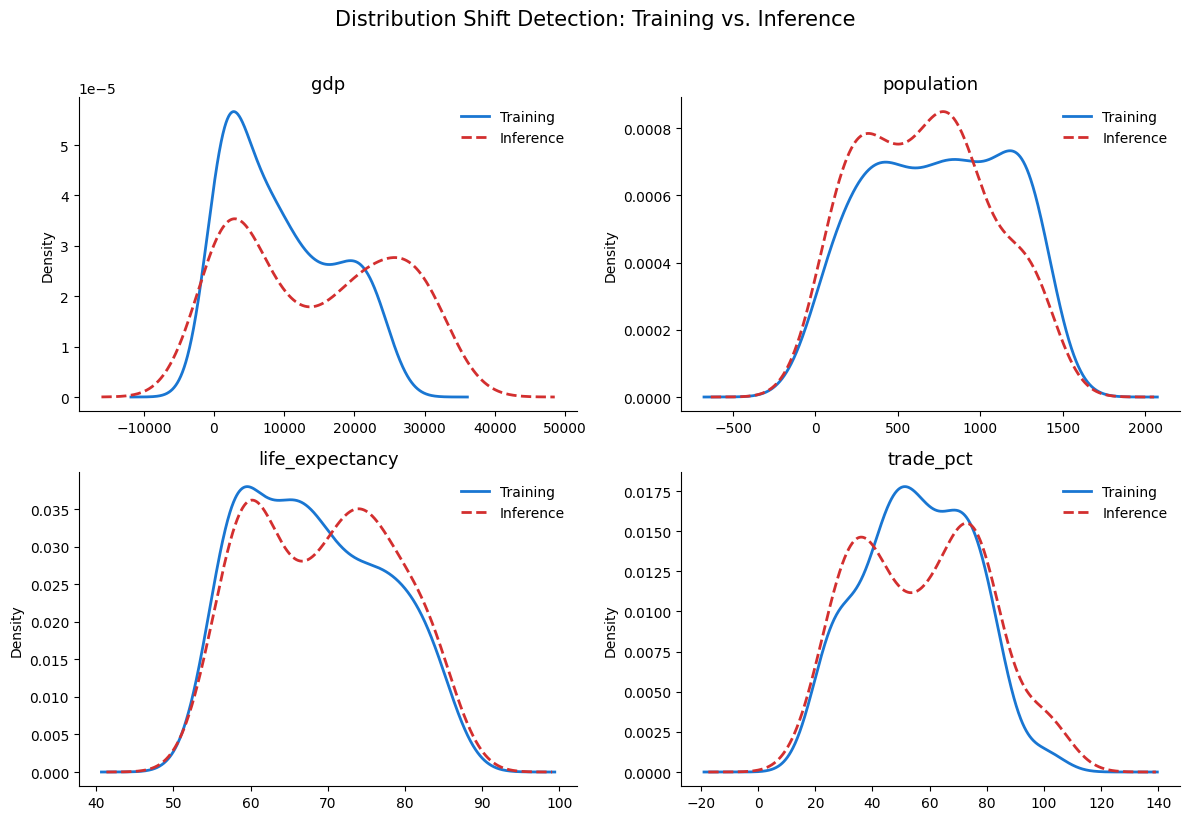

In [ ]:
# -----------------------------------------------------------
# GIVEN — run as-is: KDE overlays, training vs. inference
# Nothing to fill in. Read the four panels: which column's two curves
# have come apart, and which three sit on top of each other?
# -----------------------------------------------------------

numeric_cols = ["gdp", "population", "life_expectancy", "trade_pct"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    train[col].plot.kde(ax=ax, label="Training", color="#1976D2", linewidth=2)
    inference[col].plot.kde(ax=ax, label="Inference", color="#D32F2F",
                           linewidth=2, linestyle="--")
    ax.set_title(col, fontsize=13)
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Distribution Shift Detection: Training vs. Inference",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------------------------------
# GIVEN — run as-is: Population Stability Index (PSI)
# Nothing to fill in. PSI puts a number on what the KDE panels show.
# Your work in this part is the interpretation question below it —
# read the four values first, and be ready to say which you trust.
# -----------------------------------------------------------

def compute_psi(expected, actual, n_bins=10):
    """Compute Population Stability Index between two distributions.

    PSI = sum( (actual_i - expected_i) * ln(actual_i / expected_i) )
    where actual_i and expected_i are the proportion of observations
    in bin i.

    Parameters
    ----------
    expected : array-like
        Reference distribution (training data).
    actual : array-like
        New distribution (inference data).
    n_bins : int
        Number of bins for the histogram.

    Returns
    -------
    float
        PSI value.
    """
    # Bin edges based on expected (training) distribution
    breakpoints = np.linspace(
        min(np.min(expected), np.min(actual)),
        max(np.max(expected), np.max(actual)),
        n_bins + 1
    )

    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts = np.histogram(actual, bins=breakpoints)[0]

    # Convert to proportions, add small epsilon to avoid division by zero
    eps = 1e-4
    expected_pct = expected_counts / len(expected) + eps
    actual_pct = actual_counts / len(actual) + eps

    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi


# Compute PSI for each numeric column
print("=== Population Stability Index (PSI) ===")
print(f"{'Column':<20} {'PSI':>8}  {'Interpretation'}")
print("-" * 55)

for col in numeric_cols:
    psi_val = compute_psi(train[col].values, inference[col].values)
    if psi_val < 0.1:
        interp = "Stable"
    elif psi_val < 0.25:
        interp = "Moderate shift"
    else:
        interp = "SIGNIFICANT SHIFT"
    print(f"{col:<20} {psi_val:>8.4f}  {interp}")

=== Population Stability Index (PSI) ===
Column                    PSI  Interpretation
-------------------------------------------------------
gdp                    1.8609  SIGNIFICANT SHIFT
population             0.1280  Moderate shift
life_expectancy        0.1113  Moderate shift
trade_pct              0.3959  SIGNIFICANT SHIFT


### Verification Checkpoint

Your PSI results should show:
- **GDP:** PSI > 0.25 — the one column we deliberately shifted (multiplied by 1.3)
- **population, life_expectancy, trade_pct:** anywhere from roughly 0.05 to 0.25,
  even though *nothing was shifted in any of them*

That second line is not a typo, and it is the more useful half of this
checkpoint. Measured on this data the three untouched columns return
**0.092, 0.164 and 0.234** — two of them above the conventional 0.1
"no shift" line and one nearly at the 0.25 "significant shift" line, with no
drift applied at all.

The reason is sample size. At n = 138 against 92 over 10 bins, PSI already has
a sampling distribution whose mass sits in the low tenths from binning noise
alone. The 0.1 / 0.25 cutoffs come from credit-scoring practice at n in the
tens of thousands and do not transfer to a hundred rows.

**A drift threshold without a null distribution is a superstition.** Before
alarming on PSI in production, simulate the PSI you get from two random splits
of the *same undrifted* data and use that distribution's upper tail as the
alarm level. The GDP column is the only one here whose PSI is large enough to
survive that comparison.

If GDP shows PSI < 0.1, check your `compute_psi` implementation.

### Interpretation Questions

**Q1:** Why is detecting distribution shift important before deploying a model to production? What happens to predictions if the input distribution changes but the model doesn't know?

*Your answer here:* It is important because the distribution shift is silent if you do not actively try to detect it. The model will still work mechanically, but the predictions will be based on incorrect data, meaning they lose their predictive power. The predictions and actual outcomes will shift further apart over time if the model does not know about distribution changes.

**Q2:** A model trained on pre-COVID economic data is deployed in 2021. Which columns in our dataset likely shifted most? How would you design a monitoring system to catch this?

*Your answer here:* The biggest shifts would likely be GDP and trade_pct. COVID caused production to slow significantly during lockdowns and border closures/quarantines caused a massive drop in cross country trade. A monitoring system using PSI by column and flag it if it passes the threshold of a significant distribution shift.

## Part 3: Manual vs. Automated EDA (COMPARE — 10 min)

You just spent 20 minutes manually finding 5 bugs. Could automated profiling have caught them faster? Let's find out.

In [ ]:
!pip install ydata_profiling


In [ ]:
# -----------------------------------------------------------
# Run ydata-profiling on the ORIGINAL corrupted dataset
# -----------------------------------------------------------

try:
    from ydata_profiling import ProfileReport

    # Profile the ORIGINAL corrupted data (before your fixes)
    profile = ProfileReport(
        df,
        title="EDA Report: Corrupted Economic Dataset",
        minimal=True,  # faster for lab purposes
    )
    profile.to_notebook_iframe()

except ImportError:
    print("ydata-profiling is not installed.")
    print("To install: !pip install ydata-profiling")
    print()
    print("For this lab, answer the questions below based on what you")
    print("EXPECT the automated report would flag, given what you know")
    print("about the 5 bugs.")
    print()
    print("Quick manual summary of what a profiler would show:")
    print(f"  - GDP min: {df['gdp'].min():.2f} (negative = flagged)")
    print(f"  - Life expectancy max: {df['life_expectancy'].max():.1f} (outlier)")
    print(f"  - Duplicate rows: {df.duplicated().sum()}")
    print(f"  - trade_pct range: [{df['trade_pct'].min():.2f}, {df['trade_pct'].max():.1f}]")
    print(f"  - GDP has bimodal distribution (unit mismatch)")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 6/6 [00:00<00:00, 24197.91it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

### Interpretation Questions

**Q1:** Which of the 5 bugs would ydata-profiling have caught automatically? Which requires domain knowledge that no automated tool can provide?

| Bug | Auto-detected? | Why or why not? |
|-----|---------------|------------------|
| 1. Negative GDP |Y |Negative minimum |
| 2. Life expectancy > 120 |Y |Has extreme outliers |
| 3. Duplicate country-years |N |Need to know the structure of the dataset |
| 4. Inconsistent trade_pct |Y |Extreme outlier decimal values|
| 5. GDP unit mismatch |Y |Observable from histogram |

*Your answer here:*

**Q2:** In a production pipeline processing 1M rows daily, would you rely on manual or automated EDA? What's your monitoring strategy?

*Your answer here:* You would rely on automated EDA, as that is too much data to check manually every day. Hard constraints such as row count, null values, duplicate keys, impossibly high, low, or negative/positive values, could be run daily. Something like a PSI check could be run weekly to catch distribution shift before it becomes an issue.

## Part 4: Build eda_utils.py Module (PRODUCTION — 10 min)

Save your EDA functions as a reusable Python module. This is a portfolio artifact — production-quality code with docstrings and type hints.

In [ ]:
%%writefile eda_utils.py
"""EDA utilities for ECON 5200 labs.

Functions for data quality checking, distribution shift detection,
and automated EDA summaries.
"""

import numpy as np
import pandas as pd


def check_impossible_values(df, constraints):
    """Check columns against domain constraints and flag violations.

    Parameters
    ----------
    df : pd.DataFrame
        Input data to validate.
    constraints : dict
        Column name -> (min_val, max_val) or callable.
        If a tuple, flags rows outside [min_val, max_val].
        If a callable, flags rows where callable(value) returns False.

    Returns
    -------
    pd.DataFrame
        DataFrame with boolean columns '{col}_flagged' for each
        constrained column. True = violation detected.

    Examples
    --------
    >>> constraints = {
    ...     'gdp': (0, 100000),
    ...     'life_expectancy': (0, 100),
    ...     'trade_pct': lambda x: (x >= 0) & (x <= 100),
    ... }
    >>> flagged = check_impossible_values(df, constraints)
    """
    result = df.copy()

    for col, rule in constraints.items():
        if col not in df.columns:
            continue

        if callable(rule):
            result[f"{col}_flagged"] = ~rule(df[col])
        else:
            min_val, max_val = rule
            result[f"{col}_flagged"] = (
                (df[col] < min_val) | (df[col] > max_val)
            )

    flag_cols = [c for c in result.columns if c.endswith("_flagged")]
    n_flagged = result[flag_cols].any(axis=1).sum()
    print(f"Flagged {n_flagged} rows with constraint violations.")
    for fc in flag_cols:
        n = result[fc].sum()
        if n > 0:
            print(f"  {fc}: {n} violations")

    return result


def detect_distribution_shift(train_col, inference_col, n_bins=10):
    """Compute Population Stability Index between two distributions.

    PSI measures how much a distribution has shifted from a reference
    (training) distribution. Used in ML pipelines to detect data drift.

    PSI = sum( (actual_i - expected_i) * ln(actual_i / expected_i) )

    Parameters
    ----------
    train_col : array-like
        Reference distribution (training data).
    inference_col : array-like
        New distribution (inference/production data).
    n_bins : int, default 10
        Number of bins for histogram comparison.

    Returns
    -------
    float
        PSI value.
    str
        Interpretation: 'stable' (< 0.1), 'moderate_shift' (0.1-0.25),
        or 'significant_shift' (> 0.25).

    Examples
    --------
    >>> psi, interp = detect_distribution_shift(train['gdp'], test['gdp'])
    >>> print(f'PSI = {psi:.4f} ({interp})')
    """
    train_arr = np.asarray(train_col, dtype=float)
    inf_arr = np.asarray(inference_col, dtype=float)

    breakpoints = np.linspace(
        min(train_arr.min(), inf_arr.min()),
        max(train_arr.max(), inf_arr.max()),
        n_bins + 1,
    )

    expected_counts = np.histogram(train_arr, bins=breakpoints)[0]
    actual_counts = np.histogram(inf_arr, bins=breakpoints)[0]

    eps = 1e-4
    expected_pct = expected_counts / len(train_arr) + eps
    actual_pct = actual_counts / len(inf_arr) + eps

    psi = float(np.sum(
        (actual_pct - expected_pct) * np.log(actual_pct / expected_pct)
    ))

    if psi < 0.1:
        interpretation = "stable"
    elif psi < 0.25:
        interpretation = "moderate_shift"
    else:
        interpretation = "significant_shift"

    return psi, interpretation


def eda_summary(df):
    """Run a full EDA checklist and return a structured report.

    Checks for: missing values, duplicates, numeric outliers (IQR method),
    negative values in typically-positive columns, and basic shape info.

    Parameters
    ----------
    df : pd.DataFrame
        Input data to profile.

    Returns
    -------
    dict
        Structured report with keys: 'shape', 'dtypes', 'missing',
        'duplicates', 'numeric_summary', 'outlier_counts'.

    Examples
    --------
    >>> report = eda_summary(df)
    >>> print(report['outlier_counts'])
    """
    report = {}

    # Basic info
    report["shape"] = df.shape
    report["dtypes"] = df.dtypes.to_dict()

    # Missing values
    missing = df.isnull().sum()
    report["missing"] = missing[missing > 0].to_dict()

    # Exact duplicates
    report["duplicates"] = int(df.duplicated().sum())

    # Numeric summary
    numeric_df = df.select_dtypes(include=[np.number])
    report["numeric_summary"] = numeric_df.describe().to_dict()

    # Outlier detection (IQR method)
    outlier_counts = {}
    for col in numeric_df.columns:
        q1 = numeric_df[col].quantile(0.25)
        q3 = numeric_df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        n_outliers = int(
            ((numeric_df[col] < lower) | (numeric_df[col] > upper)).sum()
        )
        if n_outliers > 0:
            outlier_counts[col] = n_outliers
    report["outlier_counts"] = outlier_counts

    # Print summary
    print(f"Shape: {report['shape']}")
    print(f"Duplicates: {report['duplicates']}")
    if report["missing"]:
        print(f"Missing values: {report['missing']}")
    else:
        print("Missing values: None")
    if report["outlier_counts"]:
        print(f"Outliers (IQR): {report['outlier_counts']}")
    else:
        print("Outliers (IQR): None detected")

    return report

Overwriting eda_utils.py


In [ ]:
# -----------------------------------------------------------
# TEST — Verify the module works
# -----------------------------------------------------------

import importlib
import eda_utils
importlib.reload(eda_utils)

# Test 1: check_impossible_values
print("=== Test 1: check_impossible_values ===")
constraints = {
    "gdp": (0, 100000),
    "life_expectancy": (0, 100),
    "trade_pct": (0, 100),
}
flagged = eda_utils.check_impossible_values(df, constraints)
print()

# Test 2: detect_distribution_shift on shifted GDP
print("=== Test 2: detect_distribution_shift ===")
psi_val, interp = eda_utils.detect_distribution_shift(
    train["gdp"].values, inference["gdp"].values
)
print(f"GDP PSI = {psi_val:.4f} ({interp})")
assert psi_val > 0.25, f"Expected PSI > 0.25, got {psi_val:.4f}"
print("  PSI > 0.25 confirmed.")
print()

# Test 3: eda_summary
print("=== Test 3: eda_summary ===")
report = eda_utils.eda_summary(df_clean)
print(f"\nReport keys: {list(report.keys())}")

=== Test 1: check_impossible_values ===
Flagged 36 rows with constraint violations.
  gdp_flagged: 12 violations
  life_expectancy_flagged: 16 violations
  trade_pct_flagged: 10 violations

=== Test 2: detect_distribution_shift ===
GDP PSI = 1.8609 (significant_shift)
  PSI > 0.25 confirmed.

=== Test 3: eda_summary ===
Shape: (240, 6)
Duplicates: 0
Missing values: None
Outliers (IQR): None detected

Report keys: ['shape', 'dtypes', 'missing', 'duplicates', 'numeric_summary', 'outlier_counts']


### Verification Checkpoint

Your module tests should confirm:
- `check_impossible_values` flags violations in the corrupted dataset
- `detect_distribution_shift` returns PSI > 0.25 for the shifted GDP column
- `eda_summary` runs without error and returns a dict with all expected keys

If the assert on PSI fails, check your `compute_psi` / `detect_distribution_shift` binning logic.

### Before the dashboard: save the data

This notebook builds its data **in memory**. Nothing is on disk except
`eda_utils.py`, which Part 4 just wrote — so a dashboard opened on its own has
nothing to load, and a chat assistant you paste the task into cannot see the
data either.

The cell below writes the four frames next to the module and zips the lot, so
you can download it in one click and keep working outside this notebook.


In [ ]:
# -----------------------------------------------------------
# GIVEN — run as-is: save the data so the dashboard can run
#         outside this notebook
# -----------------------------------------------------------
import zipfile
from pathlib import Path

frames = {
    "pipeline_health_dirty.csv": df,          # 260 rows, all five bugs
    "pipeline_health_clean.csv": df_clean,    # after your Part 1 fixes
    "training.csv":              train,       # reference distribution
    "inference.csv":             inference,   # gdp already shifted 1.3x
}
for name, frame in frames.items():
    frame.to_csv(name, index=False)
    print(f"  wrote {name:<28} {frame.shape}")

bundle = "lab3_dashboard_bundle.zip"
with zipfile.ZipFile(bundle, "w") as z:
    for name in frames:
        z.write(name)
    if Path("eda_utils.py").exists():
        z.write("eda_utils.py")
    else:
        print("\n  eda_utils.py not found — run Part 4 first, then re-run this cell.")

print(f"\nZipped to {bundle}.")
print("Unzip it and put your dashboard in the same folder. Then:")
print('    psi, interp = eda_utils.detect_distribution_shift(train["gdp"], infer["gdp"])')
print("    # 2.4589  significant_shift")
print("\nNote the shape: detect_distribution_shift takes two COLUMNS, not two")
print("DataFrames, and returns a (value, interpretation) pair.")

# In Colab this pushes the zip straight to your browser. Outside Colab it is
# skipped, and the file is simply next to this notebook.
try:
    from google.colab import files as _colab_files
    _colab_files.download(bundle)
except Exception:
    pass

  wrote pipeline_health_dirty.csv    (260, 6)
  wrote pipeline_health_clean.csv    (240, 6)
  wrote training.csv                 (144, 6)
  wrote inference.csv                (96, 6)

Zipped to lab3_dashboard_bundle.zip.
Unzip it and put your dashboard in the same folder. Then:
    psi, interp = eda_utils.detect_distribution_shift(train["gdp"], infer["gdp"])
    # 2.4589  significant_shift

Note the shape: detect_distribution_shift takes two COLUMNS, not two
DataFrames, and returns a (value, interpretation) pair.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## AI-Assisted Expansion: Pipeline Health Dashboard

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over EDA-based corruption diagnosis, PSI distribution-shift detection, and manual vs. automated profiling. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task
Build ONE interactive dashboard, inside this notebook (ipywidgets + plotly), that lets the user:
1. Pick a numeric column and see its training vs. inference distributions overlaid
2. Move a PSI threshold slider (0.10 / 0.25) and see which columns are flagged
3. Edit the impossible-value constraints and see which rows `check_impossible_values` flags
4. Compare the corrupted `df` with your `df_clean` side by side

Import your `eda_utils` module; do not rewrite it.

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [ ]:
import ipywidgets as W
from IPython.display import display
display(W.Tab(children=[W.HTML("hello")]))
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python data scientist specializing
# in data-pipeline monitoring and distribution shift.
#
# [Request] I just completed a diagnosis-first lab where I found
# and fixed five planted corruptions in a country panel using
# EDA alone, computed the Population Stability Index between a
# training and an inference split, and wrote eda_utils.py with
# check_impossible_values(df, constraints),
# detect_distribution_shift(train_col, inference_col, n_bins)
# and eda_summary(df). Build ONE interactive dashboard in Colab:
#   1. a column dropdown overlaying train vs inference
#   2. a PSI threshold slider that lists flagged columns
#   3. editable min/max constraints feeding
#      check_impossible_values
#   4. a before/after panel comparing the dirty and clean frames
#
# The data is already in this runtime, uploaded next to
# eda_utils.py (the save cell above writes and zips it):
#   pipeline_health_dirty.csv   260 rows, all five bugs intact
#   pipeline_health_clean.csv   230 rows, after the fixes
#   training.csv                138 rows, reference distribution
#   inference.csv                92 rows, gdp already x1.3
# Load them with pandas. Do NOT assume df / df_clean / train /
# inference already exist -- I may be running this in a fresh
# notebook with only those files.
#
# [Iterate] Use ipywidgets, plotly and pandas. `import eda_utils`
# from the same folder and call it as it is -- do not reimplement
# PSI. Note the shape: detect_distribution_shift(train_col,
# inference_col, n_bins=10) takes two COLUMNS, not two DataFrames,
# and returns a (psi, interpretation) pair. Passing frames raises
# "could not convert string to float". No Streamlit, no new .py
# file, no ydata-profiling.
#
# [Mechanism Check] Add inline comments explaining:
#   - how the PSI bins are built: read eda_utils first and say
#     which sample defines the bin edges -- do not assume it is
#     the training set
#   - why the bin proportions get a small epsilon before the log
#   - why 0.10 and 0.25 are conventions, not statistical tests
#   - which of the five corruptions a PSI check would miss
#
# [Evaluate] Explain what the dashboard catches that automated
# profiling did not, and what it still cannot see.

# PASTE AI-GENERATED CODE BELOW:

# =====================================================================
# PIPELINE-HEALTH DASHBOARD  (single Colab cell: ipywidgets + plotly + pandas)
#   Tab 1  Train vs inference overlay (column dropdown)
#   Tab 2  PSI threshold slider -> flagged columns (+ optional noise floor)
#   Tab 3  Editable min/max constraints -> eda_utils.check_impossible_values
#   Tab 4  Dirty vs clean before/after (eda_summary side by side + diff table)
#   Tab 5  PSI mechanism: the actual source of detect_distribution_shift,
#          and what it implies about bin edges / epsilon
# Loads everything from CSV; assumes nothing already exists in the namespace.
# =====================================================================
import sys, os, glob, re, inspect, importlib, zipfile
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import ipywidgets as W
from IPython.display import display, clear_output, HTML

try:                                   # Colab: let widgets + plotly render inside Output
    from google.colab import output as _colab_output
    _colab_output.enable_custom_widget_manager()
    pio.renderers.default = "colab"
except Exception:
    pass

# ---------------------------------------------------------------------
# 0. Locate and import eda_utils (unzipping the save-cell archive if needed)
#    Search is shallow on purpose: a recursive glob of /content would crawl
#    a mounted Google Drive.
# ---------------------------------------------------------------------
_ROOTS = list(dict.fromkeys([os.getcwd(), "/content"]))

def _find(name):
    for root in _ROOTS:
        for pat in (os.path.join(root, name), os.path.join(root, "*", name)):
            hits = sorted(glob.glob(pat), key=len)
            if hits:
                return hits[0]
    return None

if _find("eda_utils.py") is None:
    for z in [p for r in _ROOTS for p in glob.glob(os.path.join(r, "*.zip"))]:
        with zipfile.ZipFile(z) as zf:
            if any(n.endswith("eda_utils.py") for n in zf.namelist()):
                zf.extractall(os.path.dirname(z))
                break
_utils_path = _find("eda_utils.py")
if _utils_path is None:
    raise FileNotFoundError("eda_utils.py not found in the working directory or /content.")
_utils_dir = os.path.dirname(os.path.abspath(_utils_path))
if _utils_dir not in sys.path:
    sys.path.insert(0, _utils_dir)
import eda_utils
importlib.reload(eda_utils)            # pick up edits if you re-save the module
_ROOTS.insert(0, _utils_dir)           # data files live next to eda_utils.py

# ---------------------------------------------------------------------
# 1. Load the four frames and verify their shapes against the lab spec
# ---------------------------------------------------------------------
_SPEC = {"dirty": ("pipeline_health_dirty.csv", 260),
         "clean": ("pipeline_health_clean.csv", 230),
         "train": ("training.csv", 138),
         "inference": ("inference.csv", 92)}
F, _load_msgs = {}, []
for key, (fname, n_expected) in _SPEC.items():
    p = _find(fname)
    if p is None:
        raise FileNotFoundError(f"{fname} not found next to eda_utils.py")
    F[key] = pd.read_csv(p)
    ok = len(F[key]) == n_expected
    _load_msgs.append(f"{'✅' if ok else '⚠️'} {fname}: {F[key].shape[0]}×{F[key].shape[1]}"
                      + ("" if ok else f" (expected {n_expected} rows)"))
dirty_df, clean_df, train_df, infer_df = F["dirty"], F["clean"], F["train"], F["inference"]

# ---------------------------------------------------------------------
# 2. Helpers.  detect_distribution_shift takes two COLUMNS (1-D) and returns
#    (psi, interpretation).  We only coerce to numeric and drop non-finite
#    values before the call; the PSI arithmetic is entirely eda_utils'.
# ---------------------------------------------------------------------
def _num(s):
    return pd.to_numeric(pd.Series(s), errors="coerce")

def _finite(s):
    x = _num(s).astype(float)
    return x[np.isfinite(x)].reset_index(drop=True)

def numeric_like(df, min_frac=0.5):
    """Columns where at least half the non-null values parse as numbers.
    Catches numeric columns that a corruption turned into strings."""
    out = []
    for c in df.columns:
        nn = df[c].notna().sum()
        if nn and _num(df[c]).notna().sum() / nn >= min_frac:
            out.append(c)
    return out

def psi_call(a, b, n_bins):
    a, b = _finite(a), _finite(b)
    if len(a) < 5 or len(b) < 5:
        return np.nan, "too few finite values"
    try:
        val, interp = eda_utils.detect_distribution_shift(a, b, n_bins=n_bins)
        return float(val), str(interp)
    except Exception as e:
        return np.nan, f"error: {type(e).__name__}: {e}"

_psi_cache, _null_cache = {}, {}

def psi_cached(c, n_bins):
    k = (c, n_bins)
    if k not in _psi_cache:
        _psi_cache[k] = psi_call(train_df[c], infer_df[c], n_bins)
    return _psi_cache[k]

def psi_null_p95(c, n_bins, n_perm=200, seed=0):
    """Permutation noise floor: pool train+inference, reshuffle, re-split at
    the same sizes, run eda_utils' PSI each time.  The 95th percentile is the
    PSI you'd see 1-in-20 times from sampling noise alone at n=138 vs 92."""
    k = (c, n_bins)
    if k not in _null_cache:
        a, b = _finite(train_df[c]).to_numpy(), _finite(infer_df[c]).to_numpy()
        pooled, na = np.r_[a, b], len(a)
        rng, vals = np.random.default_rng(seed), []
        for _ in range(n_perm):
            rng.shuffle(pooled)
            vals.append(psi_call(pooled[:na], pooled[na:], n_bins)[0])
        _null_cache[k] = float(np.nanpercentile(vals, 95)) if np.isfinite(vals).any() else np.nan
    return _null_cache[k]

PSI_COLS = [c for c in numeric_like(train_df) if c in numeric_like(infer_df)]
NUM_DIRTY = numeric_like(dirty_df)
CMP_COLS = [c for c in NUM_DIRTY if c in clean_df.columns]

def _overlay(a, b, name_a, name_b, title, n_bins):
    a, b = _finite(a), _finite(b)
    # Display bins only (pooled range, n_bins wide) so both histograms share an
    # x-grid.  These are NOT necessarily the PSI bins -- see Tab 5 for those.
    lo, hi = np.nanmin(np.r_[a, b]), np.nanmax(np.r_[a, b])
    size = (hi - lo) / n_bins if hi > lo else 1.0
    xb = dict(start=lo, end=hi + size * 1e-9, size=size)
    fig = go.Figure()
    fig.add_histogram(x=a, name=f"{name_a} (n={len(a)})", histnorm="probability", xbins=xb, opacity=0.6)
    fig.add_histogram(x=b, name=f"{name_b} (n={len(b)})", histnorm="probability", xbins=xb, opacity=0.6)
    fig.update_layout(barmode="overlay", title=title, height=380,
                      yaxis_title="share of rows", margin=dict(t=60, l=40, r=20, b=40),
                      legend=dict(orientation="h", y=-0.2))
    return fig

def _stats(a, b, name_a, name_b):
    a, b = _finite(a), _finite(b)
    t = pd.DataFrame({name_a: a.describe(), name_b: b.describe()}).T
    t["mean ratio vs " + name_a] = t["mean"] / t.loc[name_a, "mean"] if t.loc[name_a, "mean"] else np.nan
    return t.round(4)

# Shared bins control (Tabs 1, 2 and 4 all pass it straight to eda_utils)
nbins_w = W.IntSlider(value=10, min=3, max=20, description="n_bins", continuous_update=False)

# ---------------------------------------------------------------------
# TAB 1: train vs inference overlay
# ---------------------------------------------------------------------
col_w = W.Dropdown(options=PSI_COLS, description="column",
                   value="gdp" if "gdp" in PSI_COLS else (PSI_COLS[0] if PSI_COLS else None))
t1_out = W.Output()

def render_t1(*_):
    with t1_out:
        clear_output(wait=True)
        if not col_w.value:
            print("No numeric columns shared by training.csv and inference.csv."); return
        c, nb = col_w.value, nbins_w.value
        psi, interp = psi_cached(c, nb)
        _overlay(train_df[c], infer_df[c], "train", "inference",
                 f"{c}:  PSI = {psi:.4f}  ({interp})", nb).show()
        display(_stats(train_df[c], infer_df[c], "train", "inference"))
        # For gdp the mean ratio should sit near 1.30 -- the planted x1.3 shift.

col_w.observe(render_t1, "value"); nbins_w.observe(render_t1, "value")
tab1 = W.VBox([W.HBox([col_w, nbins_w]), t1_out])

# ---------------------------------------------------------------------
# TAB 2: PSI threshold slider -> flagged columns
# ---------------------------------------------------------------------
thr_w = W.FloatSlider(value=0.25, min=0.0, max=0.6, step=0.01, readout_format=".2f",
                      description="PSI ≥", continuous_update=False)
null_w = W.Checkbox(value=False, description="add permutation noise floor (200 shuffles/col)")
t2_out = W.Output()

def render_t2(*_):
    with t2_out:
        clear_output(wait=True)
        nb, thr, rows = nbins_w.value, thr_w.value, []
        for c in PSI_COLS:
            psi, interp = psi_cached(c, nb)
            r = {"column": c, "PSI": psi, "eda_utils says": interp, "flagged": bool(psi >= thr)}
            if null_w.value:
                p95 = psi_null_p95(c, nb)
                r["null p95"] = p95
                r["beats noise"] = bool(psi > p95)
            rows.append(r)
        t = pd.DataFrame(rows).sort_values("PSI", ascending=False, na_position="last")
        flagged = t.loc[t["flagged"], "column"].tolist()
        display(HTML(f"<b>{len(flagged)} of {len(t)} columns flagged at PSI ≥ {thr:.2f}"
                     f" (n_bins={nb}):</b> {', '.join(flagged) or '—'}"))
        display(t.style.format({"PSI": "{:.4f}", "null p95": "{:.4f}"}, na_rep="—")
                 .apply(lambda r: ["background:#fde2e2" if r["flagged"] else "" for _ in r], axis=1))
        fig = go.Figure(go.Bar(x=t["column"], y=t["PSI"],
                               marker_color=["#d62728" if f else "#7f7f7f" for f in t["flagged"]]))
        fig.add_hline(y=thr, line_dash="dash", annotation_text=f"threshold {thr:.2f}")
        for y, lab in ((0.10, "0.10 convention"), (0.25, "0.25 convention")):
            fig.add_hline(y=y, line_dash="dot", line_color="#999", annotation_text=lab,
                          annotation_position="bottom right")
        fig.update_layout(height=320, title="PSI by column (train → inference)",
                          margin=dict(t=50, l=40, r=20, b=40))
        fig.show()

for w_ in (thr_w, null_w, nbins_w):
    w_.observe(render_t2, "value")
tab2 = W.VBox([W.HBox([thr_w, nbins_w]), null_w, t2_out])

# ---------------------------------------------------------------------
# TAB 3: editable constraints -> check_impossible_values (called as-is)
# ---------------------------------------------------------------------
frame_w = W.ToggleButtons(options=["dirty", "clean"], description="frame")
coerce_w = W.Checkbox(value=False, description="coerce numeric first (off = pass the frame untouched)")
_crow = {}
for c in NUM_DIRTY:
    _crow[c] = (W.Checkbox(value=False, description=c, indent=False, layout=W.Layout(width="170px")),
                W.Text(placeholder="min (blank = none)", layout=W.Layout(width="150px")),
                W.Text(placeholder="max (blank = none)", layout=W.Layout(width="150px")))
fill_btn = W.Button(description="prefill from clean min/max", icon="magic")
run_btn = W.Button(description="run check_impossible_values", button_style="primary")
t3_out = W.Output()

def _prefill(_):
    # Circular by design: bounds taken from clean data flag nothing
    # in clean by construction. Edit them to DOMAIN bounds (population > 0,
    # life expectancy 0-120, shares 0-100 ...) before trusting the result.
    for c, (cb, lo, hi) in _crow.items():
        if c in clean_df.columns:
            x = _finite(clean_df[c])
            if len(x):
                lo.value, hi.value = f"{x.min():g}", f"{x.max():g}"
fill_btn.on_click(_prefill)

def _parse(s):
    s = s.strip()
    return float(s) if s else None

def run_constraints(_=None):
    with t3_out:
        clear_output(wait=True)
        bounds = {}
        try:
            for c, (cb, lo, hi) in _crow.items():
                if cb.value:
                    bounds[c] = (_parse(lo.value), _parse(hi.value))
        except ValueError as e:
            print(f"Could not parse a bound: {e}"); return
        if not bounds:
            print("Tick at least one column and give it a min and/or max."); return
        df = F[frame_w.value].copy()
        if coerce_w.value:
            for c in bounds:
                df[c] = _num(df[c])
        # Constraint format isn't fixed by the lab brief, so try the two common
        # shapes and report which one your function accepted.
        inf = lambda v, d: d if v is None else v
        attempts = [
            ("{col: (min, max)}", {c: (inf(l, -np.inf), inf(h, np.inf)) for c, (l, h) in bounds.items()}),
            ("{col: {'min':..,'max':..}}", {c: {"min": inf(l, -np.inf), "max": inf(h, np.inf)}
                                             for c, (l, h) in bounds.items()}),
        ]
        errs = []
        for label, cons in attempts:
            try:
                res = eda_utils.check_impossible_values(df, cons)
            except Exception as e:
                errs.append(f"{label}: {type(e).__name__}: {e}"); continue
            display(HTML(f"<small>constraints passed as <code>{label}</code> "
                         f"on the <b>{frame_w.value}</b> frame</small>"))
            if isinstance(res, pd.DataFrame):
                display(HTML(f"<b>{len(res)} rows returned</b>")); display(res.head(50))
            elif isinstance(res, dict):
                try: display(pd.DataFrame(res))
                except Exception: display(pd.Series(res, dtype=object).to_frame("result"))
            elif res is not None:
                print(res)
            return
        print("check_impossible_values rejected both constraint shapes:")
        for e in errs: print("  ", e)
        print("\nSignature:", inspect.signature(eda_utils.check_impossible_values))
        print(inspect.getdoc(eda_utils.check_impossible_values) or "(no docstring)")

run_btn.on_click(run_constraints)
_grid = W.VBox([W.HBox(list(r)) for r in _crow.values()],
               layout=W.Layout(max_height="320px", overflow_y="auto"))
tab3 = W.VBox([W.HBox([frame_w]), coerce_w, W.HBox([fill_btn, run_btn]), _grid, t3_out])

# ---------------------------------------------------------------------
# TAB 4: dirty vs clean before/after
# ---------------------------------------------------------------------
def _key_cols(df):
    return [c for c in df.columns if re.search(r"country|iso|code|year", c, re.I)]

def diff_table(nb):
    rows = []
    for c in dirty_df.columns:
        d = dirty_df[c]
        cl = clean_df[c] if c in clean_df.columns else pd.Series(dtype=object)
        dn, cn = _num(d), _num(cl)
        r = {"column": c, "dtype dirty": str(d.dtype), "dtype clean": str(cl.dtype),
             "nulls dirty": int(d.isna().sum()), "nulls clean": int(cl.isna().sum()),
             "unparseable strings dirty": int((d.notna() & dn.isna()).sum()),
             "non-finite dirty": int(np.isinf(dn.astype(float)).sum())}
        if c in CMP_COLS:
            cf = _finite(cl)
            r.update({"min dirty": dn.min(), "min clean": cf.min() if len(cf) else np.nan,
                      "max dirty": dn.max(), "max clean": cf.max() if len(cf) else np.nan,
                      "dirty outside clean range": int(((dn < cf.min()) | (dn > cf.max())).sum()) if len(cf) else np.nan,
                      "PSI clean→dirty": psi_call(cl, d, nb)[0]})
        rows.append(r)
    return pd.DataFrame(rows).set_index("column")

cmp_col_w = W.Dropdown(options=CMP_COLS, description="column")
t4_top, t4_left, t4_right, t4_bottom = W.Output(), W.Output(), W.Output(), W.Output()

def render_t4_static():
    kc = [c for c in _key_cols(dirty_df) if c in clean_df.columns]
    with t4_top:
        clear_output(wait=True)
        facts = pd.DataFrame({
            "rows": [len(dirty_df), len(clean_df)],
            "exact duplicate rows": [int(dirty_df.duplicated().sum()), int(clean_df.duplicated().sum())],
            f"duplicate keys {kc}" if kc else "duplicate keys (none detected)":
                [int(dirty_df.duplicated(kc).sum()) if kc else np.nan,
                 int(clean_df.duplicated(kc).sum()) if kc else np.nan],
        }, index=["dirty", "clean"])
        m = dirty_df.merge(clean_df.drop_duplicates(), how="left", indicator=True)
        display(facts)
        display(HTML(f"<small>{int((m['_merge'] == 'left_only').sum())} dirty rows have no exact "
                     "match in clean (removed or value-edited rows)</small>"))
    for out, df, name in ((t4_left, dirty_df, "DIRTY"), (t4_right, clean_df, "CLEAN")):
        with out:
            clear_output(wait=True)
            display(HTML(f"<b>eda_summary({name.lower()})</b>"))
            try:
                res = eda_utils.eda_summary(df)   # may print, return, or both
                if res is not None: display(res)
            except Exception as e:
                print(f"eda_summary raised {type(e).__name__}: {e}")

def render_t4(*_):
    with t4_bottom:
        clear_output(wait=True)
        nb = nbins_w.value
        display(HTML("<b>Column-level diff</b> (PSI column: which corruptions a "
                     "distribution metric would even register)"))
        display(diff_table(nb).style.format(precision=3, na_rep="—"))
        if cmp_col_w.value:
            c = cmp_col_w.value
            _overlay(clean_df[c], dirty_df[c], "clean", "dirty", f"{c}: clean vs dirty", nb).show()

cmp_col_w.observe(render_t4, "value"); nbins_w.observe(render_t4, "value")
tab4 = W.VBox([t4_top, W.HBox([t4_left, t4_right], layout=W.Layout(align_items="flex-start")),
               W.HBox([cmp_col_w, nbins_w]), t4_bottom])

# ---------------------------------------------------------------------
# TAB 5: PSI mechanism -- read eda_utils, don't assume
#
# BIN EDGES.  PSI compares two proportion vectors over ONE shared set of
#   bins, so something has to define the edges.  Three designs exist:
#   (a) quantiles of the FIRST argument (reference) -> reference proportions
#       are ~1/n_bins by construction and the metric is asymmetric;
#   (b) quantiles/range of the POOLED sample -> symmetric, but the edges move
#       whenever the inference batch moves;
#   (c) separate np.histogram(x, bins=n_bins) calls per sample -> each sample
#       gets its OWN edges, so bin i means different ranges in the two
#       samples and the PSI is not a like-for-like comparison.  That's a bug.
#   The probe below reads the source of YOUR detect_distribution_shift and
#   runs an argument-swap test.  With edges fixed, the PSI formula
#   sum((q-p)*ln(q/p)) is symmetric in p and q, so if swapping the arguments
#   changes the value, the edges depend on which argument you pass first.
#   Quantile edges also collapse on ties (integer years, zero-inflated
#   columns): np.unique on the edges silently leaves fewer than n_bins bins.
#
# EPSILON.  A bin that is empty in either sample gives ln(0) or division by
#   zero, i.e. -inf/inf/nan PSI.  Adding a small epsilon (or clipping to it)
#   keeps the term finite.  It is not neutral: an empty bin contributes about
#   q*ln(q/eps), so eps=1e-4 vs 1e-6 moves that term by q*ln(100) ≈ 4.6q.
#   With 92 inference rows and 10 bins, empty bins are common in the tails,
#   so eps choice can move PSI across a threshold.
#
# 0.10 / 0.25.  These come from credit-scorecard monitoring practice, not
#   from a sampling distribution.  PSI is the symmetric (Jeffreys) KL
#   divergence between binned proportions; nothing in it knows n.  Under NO
#   shift its expected value is roughly (n_bins-1)*(1/n_train + 1/n_inf)
#   ≈ 9*(1/138 + 1/92) ≈ 0.16 at these sample sizes (about 9/92 ≈ 0.10 if
#   reference proportions are fixed at 1/n_bins by quantile edges).  So at
#   n=92, pure sampling noise sits AT the "moderate shift" line.  The same
#   cut-offs mean different things at n=92 and n=92,000 and at 5 vs 20
#   bins.  The permutation noise floor in Tab 2 is the actual test.
#
# WHAT PSI MISSES.  Train and inference were both cut from the CLEAN frame,
#   so train-vs-inference PSI cannot see any of the five corruptions -- it
#   only sees the planted gdp x1.3.  Even pointed at dirty vs clean (Tab 4),
#   a marginal-distribution metric misses:
#     - duplicated rows (random duplication barely moves proportions);
#     - values moved between rows / swapped country or year labels
#       (the marginal is unchanged -- only the joint is wrong);
#     - missing values or strings that don't parse (dropped before binning;
#       PSI is computed on whatever survives);
#     - a handful of impossible values or sentinels (-999, 0 population):
#       a few rows dump into an outer bin and add a tiny PSI term.
#   It registers a corruption only when it moves a LOT of mass: a unit or
#   scale error on a large share of a column.  Map your five bugs onto this
#   list with Tab 4's "PSI clean→dirty" column.
# ---------------------------------------------------------------------
t5_out = W.Output()

def render_t5():
    fn = eda_utils.detect_distribution_shift
    try:
        src = inspect.getsource(fn)
    except (OSError, TypeError):
        src = ""
    params = list(inspect.signature(fn).parameters)
    a_nm, b_nm = (params + ["?", "?"])[:2]
    code = [st for ln in src.splitlines() if ln.strip() and not ln.strip().startswith("#")
            for st in ln.split(";") if st.strip()]          # one statement per entry
    # lines that DEFINE edges (not lines that merely histogram against them)
    edge_ln = [ln.strip() for ln in code
               if re.search(r"quantile|percentile|linspace|histogram_bin_edges|\.min\(|\.max\(|np\.(nan)?m(in|ax)\(", ln)
               or re.match(r"\s*[\w\s,]*(edge|bin)\w*\s*=(?!=)", ln)]
    hist_calls = [ln for ln in code if re.search(r"histogram\(", ln)]
    joined = "\n".join(edge_ln)

    def _aliases(name):
        # follow simple reassignments: `t = np.asarray(train_col)` makes t an
        # alias of train_col (and `a, b = x, y` style is handled positionally)
        names = {name}
        for ln in code:
            m = re.match(r"\s*([\w\s,]+?)\s*=(?!=)\s*(.+)", ln)
            if not m:
                continue
            lhs = [v.strip() for v in m.group(1).split(",")]
            rhs = [v.strip() for v in m.group(2).split(",")] if len(lhs) > 1 else [m.group(2)]
            for l_, r_ in zip(lhs, rhs):
                if l_ not in names and any(re.search(rf"\b{re.escape(n)}\b", r_) for n in names):
                    names.add(l_)
        return names

    def _uses(name):
        return any(re.search(rf"\b{re.escape(n)}\b", joined) for n in _aliases(name))
    uses_a, uses_b = _uses(a_nm), _uses(b_nm)
    pooled = bool(re.search(r"concat|hstack|np\.r_|append", joined))
    per_sample = (len(hist_calls) >= 2 and not edge_ln) or \
                 (len(hist_calls) >= 2 and all(re.search(r"bins\s*=\s*n_bins", h) for h in hist_calls))
    if per_sample:
        verdict = ("⚠️ each sample appears to get its OWN np.histogram edges (design c) — "
                   "proportions are not over shared bins")
    elif pooled or (uses_a and uses_b):
        verdict = "edges appear to come from BOTH samples (pooled / combined range)"
    elif uses_a:
        verdict = f"edges appear to come from the FIRST argument `{a_nm}` (the sample you pass first)"
    elif uses_b:
        verdict = f"edges appear to come from the SECOND argument `{b_nm}`"
    else:
        verdict = "could not tell from the source — read it below"
    eps = re.findall(r"(\d+(?:\.\d+)?e-\d+|\beps\w*\b|epsilon|clip\()", src)

    rng = np.random.default_rng(42)
    x, y = rng.normal(0, 1, 400), rng.normal(0.8, 2.0, 300)
    ab, ba = psi_call(x, y, 10)[0], psi_call(y, x, 10)[0]
    sym = np.isclose(ab, ba, rtol=1e-9, atol=1e-12)

    with t5_out:
        clear_output(wait=True)
        display(HTML(
            f"<b>signature:</b> <code>detect_distribution_shift{inspect.signature(fn)}</code><br>"
            f"<b>bin-edge verdict (source scan):</b> {verdict}<br>"
            f"<b>argument-swap probe:</b> PSI(x, y) = {ab:.4f}, PSI(y, x) = {ba:.4f} → "
            + ("symmetric: edges don't depend on argument order (pooled or fixed)"
               if sym else "asymmetric: the argument you pass first shapes the bins") + "<br>"
            f"<b>epsilon / clipping tokens found:</b> {', '.join(sorted(set(eps))) or 'none — check for inf/nan on empty bins'}<br>"
            f"<b>edge-building lines:</b>"))
        for ln in edge_ln or ["(none matched)"]:
            print("   ", ln)
        print("\n" + "-" * 70 + "\nfull source of eda_utils.detect_distribution_shift:\n" + "-" * 70)
        print(src or "(source not available)")

tab5 = W.VBox([t5_out])

# ---------------------------------------------------------------------
# Assemble
# ---------------------------------------------------------------------
tabs = W.Tab(children=[tab1, tab2, tab3, tab4, tab5])
for i, t in enumerate(["Train vs inference", "PSI flags", "Constraints", "Dirty vs clean", "PSI mechanism"]):
    tabs.set_title(i, t)
header = W.HTML("<h3 style='margin:4px 0'>Pipeline-health dashboard</h3><small>"
                + " &nbsp;·&nbsp; ".join(_load_msgs) + f" &nbsp;·&nbsp; eda_utils from <code>{_utils_dir}</code></small>")
display(W.VBox([header, tabs]))

render_t5(); render_t1(); render_t2(); render_t4_static(); render_t4()


### Document the interaction

Three short answers. This is what is graded for the expansion, not the code.

1. **What did the AI get wrong or leave out?** Name one line you had to change,
   or one claim in its explanation that your own output contradicts.
2. **How did you verify it?** Point to a number the dashboard shows that you
   also computed by hand earlier in this lab, and say whether they match.
3. **What would you ask differently next time?**

*Your answers here:*

1. N/A, AI generated code is not creating a dashboard
2.
3.

---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.** Replace every `[YOUR VALUE]` with the number from your own output before you paste it.

In [ ]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Found and fixed 5 planted data-quality issues in a country
#   panel using EDA alone (negative GDP, life expectancy stored in months, duplicates,
#   mixed percentage units, a GDP unit mismatch)
# * Measured distribution shift with PSI: GDP PSI = 1.8609 between
#   training and inference
# * Compared manual EDA with ydata-profiling and named what each missed
# * Wrote eda_utils.py with impossible-value, PSI and summary functions
# * Built an interactive pipeline-health dashboard
#
# **Please write a README.md entry including:**
# 1. Project Title: Pipeline Health Check — EDA, Corruption & Distribution Shift
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional data scientist wrote it."

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ5200-lab03-eda-diagnostics`

**First time?** Read the **GitHub Setup and Repository Guide** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ5200-lab03-eda-diagnostics`, tick **Add a README file**, and create it.
2. In Colab: **File → Save a copy in GitHub**. Choose `econ5200-lab03-eda-diagnostics`, branch `main`,
   commit message `Lab 03 submission`. This pushes the notebook, and the
   notebook's rendered output — charts included — is what is graded.
3. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the README prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
4. `eda_utils.py` is **not** pushed by step 2 — that step sends the notebook only,
   and the file lives in Colab's temporary storage, which is wiped when the
   session ends. Download it first: in the Colab **Files** panel (folder icon,
   left), right-click `eda_utils.py` → **Download**. Then on the repo page use
   **Add file → Upload files**, drag it in, and **Commit changes**. It is part
   of what is graded.
5. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your repository URL in the **Comments**
   box beside the upload. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install.

---

**Lab 3 complete!** You've diagnosed 5 data corruption bugs through EDA alone, built a distribution shift detector using PSI, compared manual vs. automated profiling, and produced a reusable `eda_utils.py` module. These skills transfer directly to any data pipeline monitoring or ML production role.